# FreeVIZ and SPCA comparison

In this notebook, we compare resulting vizualizations of FreeViz and SPCA for classification on four datasets.

In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import torch
import matplotlib.pyplot as plt
import numpy as np

import importlib
import utils
importlib.reload(utils)

from models import Freeviz
from models.spca_classification import SPCA_Classification
from utils import load_zoo_data, load_car_data, load_mushroom_data, load_glass_data, load_breast_cancer_data, scale_features, plot_projection, select_lambda

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

/home/jasa/.local/lib/python3.10/site-packages/torch/cuda/__init__.py:174: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0


# The ZOO dataset

#### Data preparation

In [3]:
E_raw, C, names, feature_names, class_names = load_zoo_data(device)
E = scale_features(E_raw)

In [4]:
# Select optimal lambda for SPCA on Zoo data
E_zoo_f64 = E.to(torch.float64)
best_lam_zoo = select_lambda(SPCA_Classification, E_zoo_f64, C,
                             num_classes=len(class_names), steps=500)


/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Step 0: loss = 1.8620, classifier loss = 1.8549
Step 10: loss = 1.1978, classifier loss = 1.1880


Step 20: loss = 0.9332, classifier loss = 0.9226
Step 30: loss = 0.8008, classifier loss = 0.7900


Step 40: loss = 0.6896, classifier loss = 0.6784
Step 50: loss = 0.5934, classifier loss = 0.5813


Step 60: loss = 0.5187, classifier loss = 0.5062
Step 70: loss = 0.4585, classifier loss = 0.4457


...

Step 260: loss = 1050.8229, classifier loss = 0.3794
Step 270: loss = 1050.8218, classifier loss = 0.3783
Step 280: loss = 1050.8207, classifier loss = 0.3772
Step 290: loss = 1050.8196, classifier loss = 0.3762
Step 300: loss = 1050.8186, classifier loss = 0.3751


Step 310: loss = 1050.8175, classifier loss = 0.3741
Step 320: loss = 1050.8165, classifier loss = 0.3730
Step 330: loss = 1050.8155, classifier loss = 0.3720
Step 340: loss = 1050.8145, classifier loss = 0.3710
Step 350: loss = 1050.8135, classifier loss = 0.3700


Step 360: loss = 1050.8125, classifier loss = 0.3691
Step 370: loss = 1050.8116, classifier loss = 0.3681
Step 380: loss = 1050.8106, classifier loss = 0.3671
Step 390: loss = 1050.8097, classifier loss = 0.3662
Step 400: loss = 1050.8087, classifier loss = 0.3652


Step 410: loss = 1050.8078, classifier loss = 0.3643
Step 420: loss = 1050.8069, classifier loss = 0.3634
Step 430: loss = 1050.8060, classifier loss = 0.3625
Step 440: loss = 1050.8051, classifier loss = 0.3616
Step 450: loss = 1050.8042, classifier loss = 0.3607


Step 460: loss = 1050.8033, classifier loss = 0.3598
Step 470: loss = 1050.8025, classifier loss = 0.3590
Step 480: loss = 1050.8016, classifier loss = 0.3581
Step 490: loss = 1050.8008, classifier loss = 0.3573
lambda = 10.000000:  var_exp = 0.5853,  accuracy = 0.8095

Best lambda = 0.006579 (sum = 1.4623)


#### Train FreeVIZ

In [5]:
freeviz = Freeviz(E.shape[1]).to(device)
freeviz.train(E, C)

P = freeviz(E)
A = freeviz.A
P_np = P.detach().cpu().numpy()
C_np = C.detach().cpu().numpy()
A_np = A.detach().cpu().numpy()

step: 1 loss: 18686.888671875
step: 2 loss: 18908.298828125


step: 3 loss: 20747.65625
step: 4 loss: 19673.408203125
step: 5 loss: 12314.7578125
step: 6 loss: 11629.3037109375
step: 7 loss: 12073.1474609375
step: 8 loss: 12357.669921875
step: 9 loss: 12604.470703125
step: 10 loss: 12704.3095703125
step: 11 loss: 12857.6171875


#### Train SPCA Classification

In [6]:
model = SPCA_Classification(input_dim=E.shape[1], latent_dim=2, num_classes=len(class_names), lr=0.05).to(device)
E_centered = E - E.mean(dim=0)
lam = best_lam_zoo
steps = 1000
model.train(E_centered, C, lam=lam, steps=steps, classifier_epochs=50)

L = model.L.detach().clone()
L = L - L.mean(dim=0, keepdim=True)
loading_norms = torch.norm(L, dim=1)
L = L / loading_norms.max()

Z = E_centered @ L
z_max = torch.abs(Z).max()
Z = Z / z_max

Z_np = Z.cpu().numpy()
C_np_spca = C.cpu().numpy()
L_np = L.cpu().numpy()

Step 0: loss = 2.7055, classifier loss = 1.8519


Step 10: loss = 2.0416, classifier loss = 1.1832


Step 20: loss = 1.7734, classifier loss = 0.9117


Step 30: loss = 1.6472, classifier loss = 0.7842


Step 40: loss = 1.5708, classifier loss = 0.7066


...

Step 780: loss = 1.0806, classifier loss = 0.1388
Step 790: loss = 1.0799, classifier loss = 0.1382
Step 800: loss = 1.0792, classifier loss = 0.1376
Step 810: loss = 1.0785, classifier loss = 0.1370
Step 820: loss = 1.0778, classifier loss = 0.1364
Step 830: loss = 1.0771, classifier loss = 0.1358


Step 840: loss = 1.0764, classifier loss = 0.1351
Step 850: loss = 1.0758, classifier loss = 0.1345
Step 860: loss = 1.0751, classifier loss = 0.1339
Step 870: loss = 1.0744, classifier loss = 0.1333
Step 880: loss = 1.0738, classifier loss = 0.1327


Step 890: loss = 1.0731, classifier loss = 0.1321
Step 900: loss = 1.0725, classifier loss = 0.1315
Step 910: loss = 1.0718, classifier loss = 0.1310
Step 920: loss = 1.0712, classifier loss = 0.1304
Step 930: loss = 1.0706, classifier loss = 0.1298


Step 940: loss = 1.0700, classifier loss = 0.1293
Step 950: loss = 1.0693, classifier loss = 0.1288
Step 960: loss = 1.0687, classifier loss = 0.1281
Step 970: loss = 1.0681, classifier loss = 0.1277
Step 980: loss = 1.0675, classifier loss = 0.1271


Step 990: loss = 1.0669, classifier loss = 0.1266


### Side-by-side comparison

/usr/lib/python3/dist-packages/matplotlib/transforms.py:627: RuntimeWarning: invalid value encountered in scalar subtract
  deltaw = (sw * width - width) / 2.0
/usr/lib/python3/dist-packages/matplotlib/transforms.py:628: RuntimeWarning: invalid value encountered in scalar subtract
  deltah = (sh * height - height) / 2.0
Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


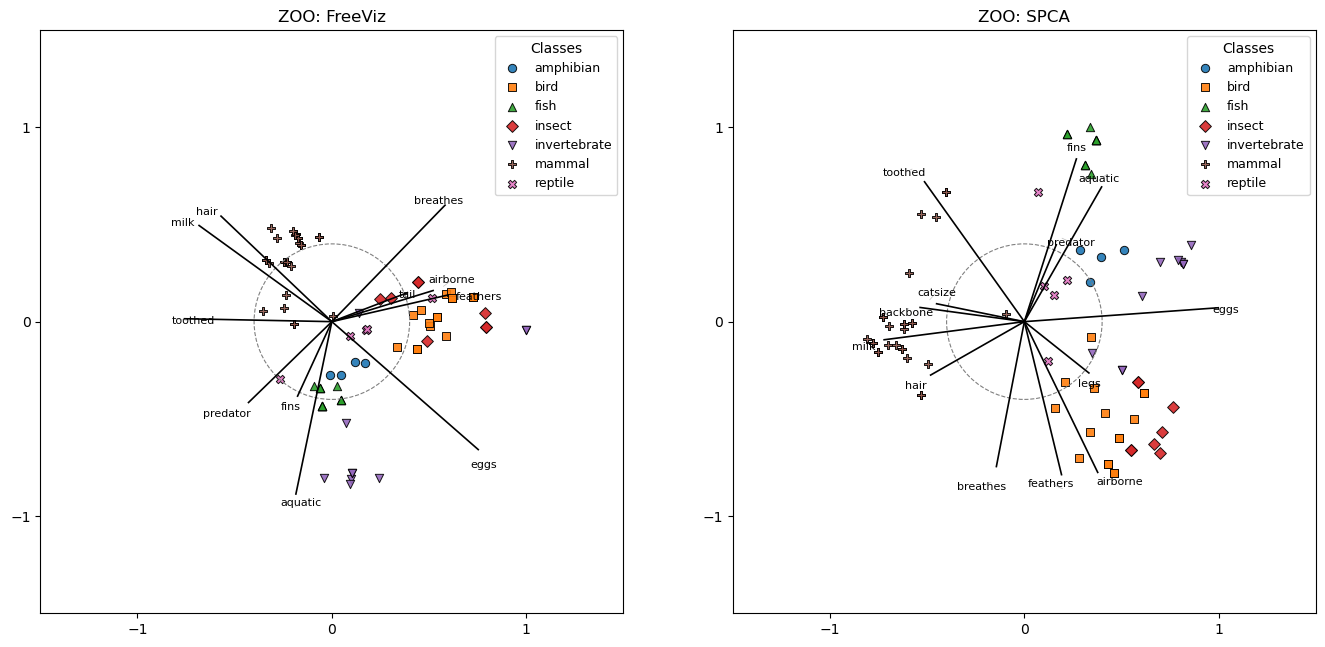

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6.5))

plot_projection(
    P_np, A_np, feature_names, C_np, class_names,
    title='ZOO: FreeViz', ax=ax1, text_scale=1.08, normalize_points=True
)

plot_projection(
    Z_np, L_np, feature_names, C_np_spca, class_names,
    title='ZOO: SPCA', ax=ax2, text_scale=1.1
)

plt.tight_layout()
plt.savefig("../final_vizualizations/compare_freeviz_spca_zoo.svg", format="svg", bbox_inches="tight")
plt.savefig("../final_vizualizations/compare_freeviz_spca_zoo.svg", format="svg", bbox_inches="tight")
plt.show()

# The MUSHROOM dataset

#### Data preparation

In [8]:
E_mush, C_mush, names_mush, feature_names_mush, class_names_mush = load_mushroom_data(device)
E_mush = scale_features(E_mush)

In [9]:
# Select optimal lambda for SPCA on Mushroom data
E_mush_f64 = E_mush.to(torch.float64)
best_lam_mush = select_lambda(SPCA_Classification, E_mush_f64, C_mush,
                             num_classes=len(class_names_mush), steps=500)


Step 0: loss = 1.2690, classifier loss = 0.6500


Step 10: loss = 0.9802, classifier loss = 0.3532


Step 20: loss = 0.8819, classifier loss = 0.2445


Step 30: loss = 0.8337, classifier loss = 0.1879


Step 40: loss = 0.8042, classifier loss = 0.1521


...

Step 420: loss = 62051.2791, classifier loss = 0.2934
Step 430: loss = 62051.2791, classifier loss = 0.2934


Step 440: loss = 62051.2791, classifier loss = 0.2934
Step 450: loss = 62051.2791, classifier loss = 0.2934


Step 460: loss = 62051.2791, classifier loss = 0.2934
Step 470: loss = 62051.2791, classifier loss = 0.2934


Step 480: loss = 62051.2791, classifier loss = 0.2934
Step 490: loss = 62051.2791, classifier loss = 0.2934


lambda = 10.000000:  var_exp = 0.3289,  accuracy = 0.8750

Best lambda = 0.000100 (sum = 1.2381)


#### Train FreeVIZ

In [10]:
freeviz_mush = Freeviz(E_mush.shape[1]).to(device)
freeviz_mush.train(E_mush, C_mush)

P_mush = freeviz_mush(E_mush)
A_mush = freeviz_mush.A
P_mush_np = P_mush.detach().cpu().numpy()
C_mush_np = C_mush.detach().cpu().numpy()
A_mush_np = A_mush.detach().cpu().numpy()

step: 1 loss: 11156905.0


step: 2 loss: 2272079.75
step: 3 loss: 2261446.25


step: 4 loss: 2273533.5
step: 5 loss: 2274354.5


step: 6 loss: 2257592.5
step: 7 loss: 2247793.75


step: 8 loss: 2246795.5
step: 9 loss: 2227085.5


step: 10 loss: 2224087.5


step: 11 loss: 2188089.0


#### Train SPCA Classification

In [11]:
model_mush = SPCA_Classification(input_dim=E_mush.shape[1], latent_dim=2, num_classes=len(class_names_mush), lr=0.05).to(device)
E_mush_centered = E_mush - E_mush.mean(dim=0)
model_mush.train(E_mush_centered, C_mush, lam=best_lam_mush, steps=1000, classifier_epochs=50)

L_mush = model_mush.L.detach().clone()
L_mush = L_mush - L_mush.mean(dim=0, keepdim=True)
loading_norms_mush = torch.norm(L_mush, dim=1)
L_mush = L_mush / loading_norms_mush.max()

Z_mush = E_mush_centered @ L_mush
z_max_mush = torch.abs(Z_mush).max()
Z_mush = Z_mush / z_max_mush

Z_mush_np = Z_mush.cpu().numpy()
C_mush_np_spca = C_mush.cpu().numpy()
L_mush_np = L_mush.cpu().numpy()

Step 0: loss = 1.4198, classifier loss = 0.6504


Step 10: loss = 1.1323, classifier loss = 0.3557


Step 20: loss = 1.0388, classifier loss = 0.2519


Step 30: loss = 0.9950, classifier loss = 0.1990


Step 40: loss = 0.9687, classifier loss = 0.1653


...

Step 810: loss = 0.8777, classifier loss = 0.0473
Step 820: loss = 0.8772, classifier loss = 0.0467
Step 830: loss = 0.8767, classifier loss = 0.0462
Step 840: loss = 0.8762, classifier loss = 0.0456


Step 850: loss = 0.8757, classifier loss = 0.0450
Step 860: loss = 0.8753, classifier loss = 0.0445
Step 870: loss = 0.8748, classifier loss = 0.0440
Step 880: loss = 0.8743, classifier loss = 0.0435


Step 890: loss = 0.8739, classifier loss = 0.0430
Step 900: loss = 0.8734, classifier loss = 0.0425
Step 910: loss = 0.8730, classifier loss = 0.0419
Step 920: loss = 0.8725, classifier loss = 0.0415


Step 930: loss = 0.8721, classifier loss = 0.0410
Step 940: loss = 0.8717, classifier loss = 0.0405
Step 950: loss = 0.8712, classifier loss = 0.0400
Step 960: loss = 0.8708, classifier loss = 0.0396


Step 970: loss = 0.8704, classifier loss = 0.0391
Step 980: loss = 0.8700, classifier loss = 0.0387
Step 990: loss = 0.8696, classifier loss = 0.0382


### Side-by-side comparison

/usr/lib/python3/dist-packages/matplotlib/transforms.py:627: RuntimeWarning: invalid value encountered in scalar subtract
  deltaw = (sw * width - width) / 2.0
/usr/lib/python3/dist-packages/matplotlib/transforms.py:628: RuntimeWarning: invalid value encountered in scalar subtract
  deltah = (sh * height - height) / 2.0


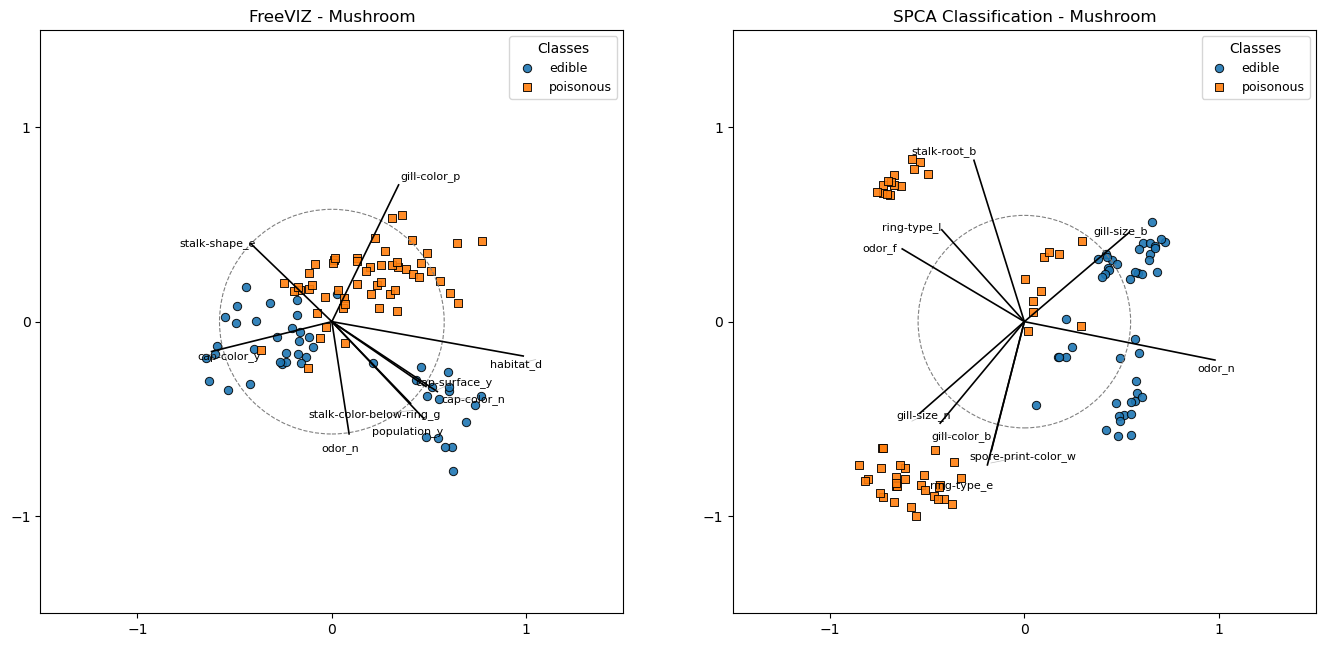

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6.5))

plot_projection(
    points=P_mush_np, vectors=A_mush_np, feature_names=feature_names_mush,
    class_codes=C_mush_np, class_names=class_names_mush,
    title='FreeVIZ - Mushroom', ax=ax1, text_scale=1.08, top_n_loadings=10, normalize_points=True
)

plot_projection(
    points=Z_mush_np, vectors=L_mush_np, feature_names=feature_names_mush,
    class_codes=C_mush_np_spca, class_names=class_names_mush,
    title='SPCA Classification - Mushroom', ax=ax2, text_scale=1.1, top_n_loadings=10
)

plt.tight_layout()
plt.savefig("../final_vizualizations/compare_freeviz_spca_mushroom.svg", format="svg", bbox_inches="tight")
plt.savefig("../final_vizualizations/compare_freeviz_spca_mushroom.svg", format="svg", bbox_inches="tight")
plt.show()

# The BREAST CANCER dataset

#### Data preparation

In [13]:
E_bc, C_bc, names_bc, feature_names_bc, class_names_bc = load_breast_cancer_data(device)
E_bc = scale_features(E_bc)

In [14]:
# Select optimal lambda for SPCA on Breast Cancer data
E_bc_f64 = E_bc.to(torch.float64)
best_lam_bc = select_lambda(SPCA_Classification, E_bc_f64, C_bc,
                             num_classes=len(class_names_bc), steps=500)


Step 0: loss = 0.6687, classifier loss = 0.6673


Step 10: loss = 0.5226, classifier loss = 0.5209


Step 20: loss = 0.4399, classifier loss = 0.4380


Step 30: loss = 0.3813, classifier loss = 0.3795


Step 40: loss = 0.3380, classifier loss = 0.3361


...

Step 270: loss = 194.4225, classifier loss = 0.2091
Step 280: loss = 194.4217, classifier loss = 0.2083
Step 290: loss = 194.4210, classifier loss = 0.2076
Step 300: loss = 194.4203, classifier loss = 0.2068
Step 310: loss = 194.4195, classifier loss = 0.2061


Step 320: loss = 194.4188, classifier loss = 0.2054
Step 330: loss = 194.4182, classifier loss = 0.2047
Step 340: loss = 194.4175, classifier loss = 0.2041
Step 350: loss = 194.4168, classifier loss = 0.2034
Step 360: loss = 194.4162, classifier loss = 0.2028


Step 370: loss = 194.4156, classifier loss = 0.2022
Step 380: loss = 194.4150, classifier loss = 0.2016
Step 390: loss = 194.4144, classifier loss = 0.2010
Step 400: loss = 194.4139, classifier loss = 0.2004
Step 410: loss = 194.4133, classifier loss = 0.1999


Step 420: loss = 194.4128, classifier loss = 0.1993
Step 430: loss = 194.4122, classifier loss = 0.1988
Step 440: loss = 194.4117, classifier loss = 0.1983
Step 450: loss = 194.4112, classifier loss = 0.1978
Step 460: loss = 194.4107, classifier loss = 0.1973


Step 470: loss = 194.4103, classifier loss = 0.1968
Step 480: loss = 194.4098, classifier loss = 0.1964
Step 490: loss = 194.4094, classifier loss = 0.1959
lambda = 10.000000:  var_exp = 0.8329,  accuracy = 0.9561

Best lambda = 0.053367 (sum = 1.7980)


#### Train FreeVIZ

In [15]:
freeviz_bc = Freeviz(E_bc.shape[1]).to(device)
freeviz_bc.train(E_bc, C_bc)

P_bc = freeviz_bc(E_bc)
A_bc = freeviz_bc.A
P_bc_np = P_bc.detach().cpu().numpy()
C_bc_np = C_bc.detach().cpu().numpy()
A_bc_np = A_bc.detach().cpu().numpy()

step: 1 loss: 716257.625
step: 2 loss: 1011298.5625
step: 3 loss: 869791.8125


step: 4 loss: 802809.5
step: 5 loss: 806706.25
step: 6 loss: 786447.0


step: 7 loss: 750849.4375
step: 8 loss: 656695.0625
step: 9 loss: 697658.25


step: 10 loss: 658344.75
step: 11 loss: 681721.625


#### Train SPCA Classification

In [16]:
model_bc = SPCA_Classification(input_dim=E_bc.shape[1], latent_dim=2, num_classes=len(class_names_bc), lr=0.05).to(device)
E_bc_centered = E_bc - E_bc.mean(dim=0)
model_bc.train(E_bc_centered, C_bc, lam=best_lam_bc, steps=1000, classifier_epochs=50)

L_bc = model_bc.L.detach().clone()
L_bc = L_bc - L_bc.mean(dim=0, keepdim=True)
loading_norms_bc = torch.norm(L_bc, dim=1)
L_bc = L_bc / loading_norms_bc.max()

Z_bc = E_bc_centered @ L_bc
z_max_bc = torch.abs(Z_bc).max()
Z_bc = Z_bc / z_max_bc

Z_bc_np = Z_bc.cpu().numpy()
C_bc_np_spca = C_bc.cpu().numpy()
L_bc_np = L_bc.cpu().numpy()

Step 0: loss = 1.9637, classifier loss = 0.6679


Step 10: loss = 1.8162, classifier loss = 0.5201


Step 20: loss = 1.7332, classifier loss = 0.4370


Step 30: loss = 1.6749, classifier loss = 0.3786


Step 40: loss = 1.6320, classifier loss = 0.3358


...

Step 770: loss = 1.4700, classifier loss = 0.1733
Step 780: loss = 1.4698, classifier loss = 0.1730
Step 790: loss = 1.4695, classifier loss = 0.1728
Step 800: loss = 1.4693, classifier loss = 0.1726
Step 810: loss = 1.4691, classifier loss = 0.1724


Step 820: loss = 1.4689, classifier loss = 0.1722
Step 830: loss = 1.4687, classifier loss = 0.1720
Step 840: loss = 1.4685, classifier loss = 0.1718
Step 850: loss = 1.4683, classifier loss = 0.1716
Step 860: loss = 1.4682, classifier loss = 0.1714


Step 870: loss = 1.4680, classifier loss = 0.1712
Step 880: loss = 1.4678, classifier loss = 0.1711
Step 890: loss = 1.4677, classifier loss = 0.1709
Step 900: loss = 1.4675, classifier loss = 0.1707


Step 910: loss = 1.4674, classifier loss = 0.1706
Step 920: loss = 1.4672, classifier loss = 0.1704
Step 930: loss = 1.4671, classifier loss = 0.1703
Step 940: loss = 1.4670, classifier loss = 0.1702


Step 950: loss = 1.4668, classifier loss = 0.1700
Step 960: loss = 1.4667, classifier loss = 0.1699
Step 970: loss = 1.4666, classifier loss = 0.1698
Step 980: loss = 1.4665, classifier loss = 0.1697
Step 990: loss = 1.4664, classifier loss = 0.1695


### Side-by-side comparison

/usr/lib/python3/dist-packages/matplotlib/transforms.py:627: RuntimeWarning: invalid value encountered in scalar subtract
  deltaw = (sw * width - width) / 2.0
/usr/lib/python3/dist-packages/matplotlib/transforms.py:628: RuntimeWarning: invalid value encountered in scalar subtract
  deltah = (sh * height - height) / 2.0


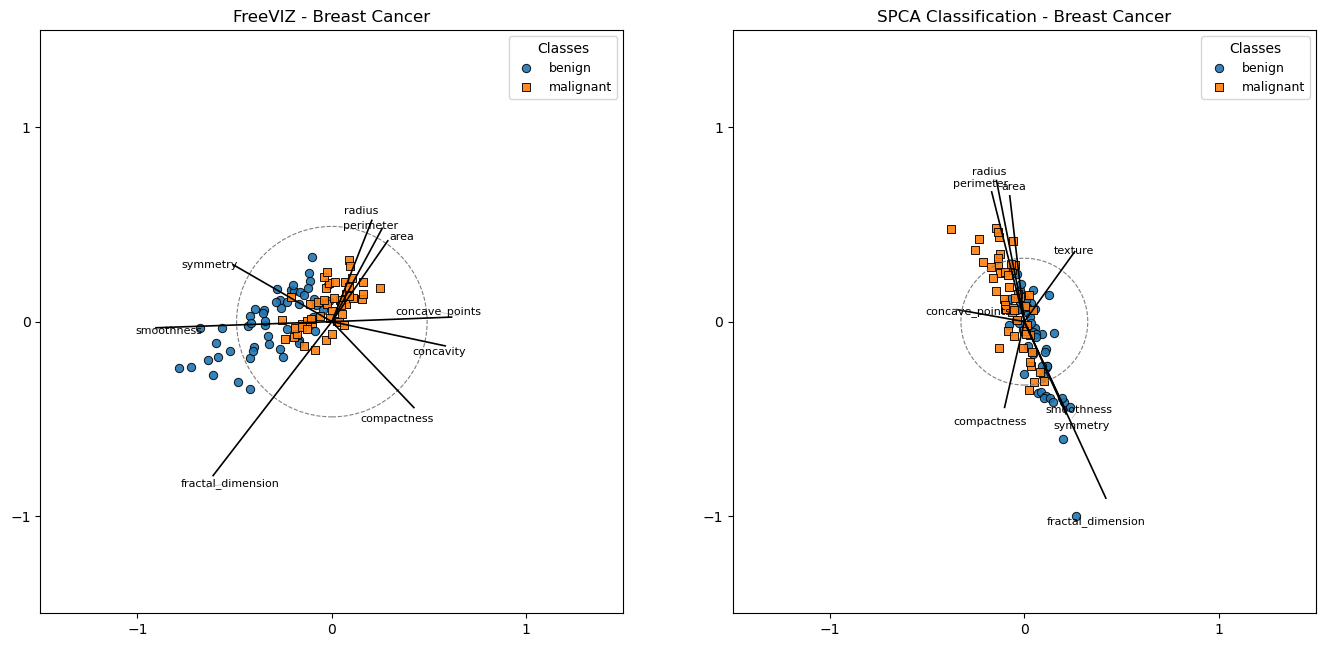

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6.5))

plot_projection(
    points=P_bc_np, vectors=A_bc_np, feature_names=feature_names_bc,
    class_codes=C_bc_np, class_names=class_names_bc,
    title='FreeVIZ - Breast Cancer', ax=ax1, text_scale=1.08, top_n_loadings=10, normalize_points=True
)

plot_projection(
    points=Z_bc_np, vectors=L_bc_np, feature_names=feature_names_bc,
    class_codes=C_bc_np_spca, class_names=class_names_bc,
    title='SPCA Classification - Breast Cancer', ax=ax2, text_scale=1.1, top_n_loadings=10
)

plt.tight_layout()
plt.savefig("../final_vizualizations/compare_freeviz_spca_car.svg", format="svg", bbox_inches="tight")
plt.savefig("../final_vizualizations/compare_freeviz_spca_breast_cancer.svg", format="svg", bbox_inches="tight")
plt.show()